# Homework 11 — Evaluation & Risk Communication

## Objective

This notebook quantifies uncertainty around a baseline regression, tests sensitivity to alternative assumptions, checks subgroup performance, and translates the findings into stakeholder-facing risk language.

The workflow follows the Stage 11 assignment:

**Baseline → Gaussian vs Bootstrap CI → Bootstrap Metric → Scenario Sensitivity → Subgroup Diagnostics → Risk Communication**

The course-provided synthetic fallback is used so the analysis is fully reproducible. It contains approximately 5% missing predictor values and fat-tailed Student-\(t\) noise, making it appropriate for comparing Gaussian-based and bootstrap-based uncertainty estimates.

### Reproducibility

- Random seed: `111`
- Bootstrap metric resamples: `2,000`
- Bootstrap prediction-band resamples: `1,500`
- Helper functions are saved in `src/evaluation.py`
- Scenario outputs are saved in `data/processed/scenario_results.csv`
- Key figures are saved in `reports/`

**Source note:** The data-generating process is adapted from the course-provided Stage 11 homework starter. The corrected scenario evaluation, expanded bootstrap analysis, subgroup uncertainty, visuals, and stakeholder interpretation are developed for this submission.


## 1. Setup and helper functions

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 111
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 5)

# Robustly locate homework/homework11 whether the notebook is launched
# from its own folder or from the repository root.
cwd = Path.cwd()
if (cwd / "src" / "evaluation.py").exists():
    HOMEWORK_DIR = cwd
elif (cwd / "homework" / "homework11" / "src" / "evaluation.py").exists():
    HOMEWORK_DIR = cwd / "homework" / "homework11"
else:
    HOMEWORK_DIR = cwd

sys.path.insert(0, str(HOMEWORK_DIR / "src"))

from evaluation import (
    SimpleLinReg,
    mean_impute,
    median_impute,
    mae,
    rmse,
    bias,
    bootstrap_abs_error_ci,
    gaussian_mean_prediction_ci,
    bootstrap_prediction_band,
)

RAW_DIR = HOMEWORK_DIR / "data" / "raw"
PROCESSED_DIR = HOMEWORK_DIR / "data" / "processed"
REPORTS_DIR = HOMEWORK_DIR / "reports"

for p in [RAW_DIR, PROCESSED_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Random seed:", SEED)
print("Homework directory:", HOMEWORK_DIR.resolve())


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\yifunger\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Random seed: 111
Homework directory: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework11


## 2. Load data or generate the course synthetic fallback

The synthetic fallback preserves the starter's structure:

- 180 daily observations
- categorical segments A/B/C
- one continuous predictor, `x_feature`
- approximately 5% missing values in the predictor
- a target that is approximately linear in \(x\)
- fat-tailed Student-\(t\) errors with 3 degrees of freedom

The fat-tailed noise is important because Gaussian uncertainty assumptions may be less reliable when extreme residuals occur.


In [2]:
csv_path = RAW_DIR / "data_stage11_eval_risk.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=["date"])
else:
    # Reset seed immediately before generation so the fallback is deterministic.
    np.random.seed(SEED)

    n = 180
    dates = pd.date_range("2022-06-01", periods=n, freq="D")
    segment = np.random.choice(["A", "B", "C"], size=n, p=[0.5, 0.3, 0.2])
    x = np.linspace(0, 9, n) + np.random.normal(0, 0.7, n)
    y = 2.1 * x + 0.8 + np.random.standard_t(df=3, size=n) * 1.1

    missing_idx = np.random.choice(
        np.arange(n), size=round(0.05 * n), replace=False
    )
    x[missing_idx] = np.nan

    df = pd.DataFrame({
        "date": dates,
        "segment": segment,
        "x_feature": x,
        "y_target": y,
    })
    df.to_csv(csv_path, index=False)

print("Rows:", len(df))
print("Missing x_feature:", int(df["x_feature"].isna().sum()))
print("Missing rate:", f'{df["x_feature"].isna().mean():.1%}')
print("\nSegment counts:")
print(df["segment"].value_counts().sort_index())
df.head()


Rows: 180
Missing x_feature: 9
Missing rate: 5.0%

Segment counts:
segment
A    94
B    41
C    45
Name: count, dtype: int64


,date,segment,x_feature,y_target
0,2022-06-01,B,0.547868,2.107524
1,2022-06-02,A,0.974480,2.209111
2,2022-06-03,A,-0.012991,0.867315
3,2022-06-04,B,-1.012503,-1.741932
4,2022-06-05,A,0.642399,1.615007


## 3. Baseline fit

### Baseline assumption

Missing predictor values are replaced with the **sample mean**, and a simple linear regression is fit:

\[
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i.
\]

The primary error metric is **MAE**, because it is easy to explain in the original target units and is less dominated by extreme observations than squared-error metrics.


In [3]:
X_raw = df["x_feature"].to_numpy(dtype=float)
y = df["y_target"].to_numpy(dtype=float)

X_base = mean_impute(X_raw)
base_model = SimpleLinReg().fit(X_base, y)
y_hat = base_model.predict(X_base)
residuals = y - y_hat

df_eval = df.copy()
df_eval["x_imputed"] = X_base
df_eval["y_hat"] = y_hat
df_eval["residual"] = residuals
df_eval["abs_error"] = np.abs(residuals)

baseline_summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "Mean residual (bias)", "Slope", "Intercept"],
    "value": [
        mae(y, y_hat),
        rmse(y, y_hat),
        bias(y, y_hat),
        base_model.coef_[0],
        base_model.intercept_,
    ],
})
baseline_summary


,metric,value
0,MAE,1.278317e+00
1,RMSE,2.081919e+00
2,Mean residual (bias),-4.302731e-15
3,Slope,2.130236e+00
4,Intercept,7.115234e-01


### Baseline takeaway

The baseline MAE is approximately **1.278 target units**. The estimated slope is about **2.13**, close to the underlying synthetic relationship of 2.1.

However, a single MAE value hides uncertainty. The next sections quantify how much the reported performance and fitted relationship could move under resampling and alternative assumptions.


## 4. Gaussian-based vs bootstrap-based confidence intervals

Two uncertainty assumptions are compared for the fitted mean response:

1. **Gaussian-based CI:** uses the standard linear-regression approximation and \(1.96 \times SE\).
2. **Bootstrap CI:** repeatedly resamples paired observations, **recomputes mean imputation inside each bootstrap sample**, refits the model, and takes percentile bands.

The bootstrap requires fewer distributional assumptions, but the ordinary row bootstrap still assumes observations are exchangeable. If the real project data have strong time dependence, a block bootstrap would be more appropriate.


In [4]:
x_grid = np.linspace(np.nanmin(X_raw), np.nanmax(X_raw), 150)

pred_line, gauss_lo, gauss_hi = gaussian_mean_prediction_ci(
    X_base, y, x_grid
)

boot_mean, boot_lo, boot_hi = bootstrap_prediction_band(
    X_raw,
    y,
    x_grid,
    n_boot=1500,
    seed=SEED,
)

ci_width_summary = pd.DataFrame({
    "method": ["Gaussian-based", "Bootstrap percentile"],
    "average_CI_width": [
        float(np.mean(gauss_hi - gauss_lo)),
        float(np.mean(boot_hi - boot_lo)),
    ],
})
ci_width_summary


,method,average_CI_width
0,Gaussian-based,0.919590
1,Bootstrap percentile,0.816142


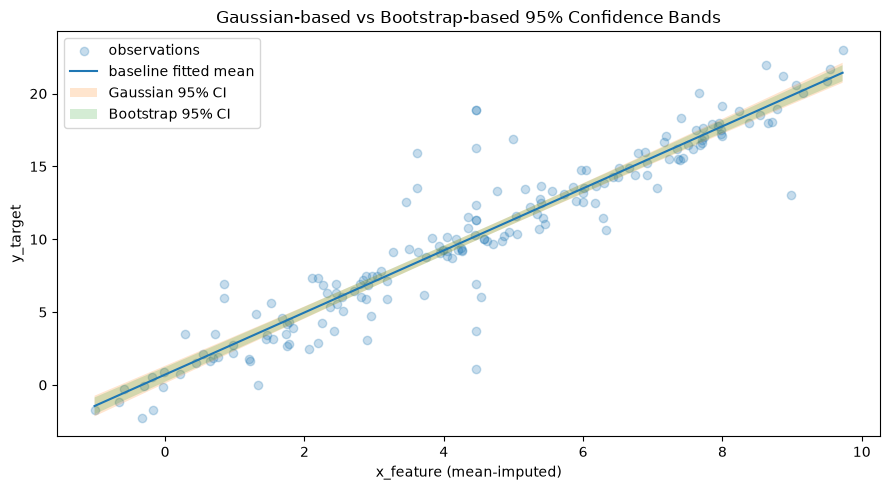

In [5]:
plt.figure(figsize=(9, 5))
plt.scatter(X_base, y, alpha=0.25, label="observations")
plt.plot(x_grid, pred_line, label="baseline fitted mean")
plt.fill_between(
    x_grid, gauss_lo, gauss_hi, alpha=0.20, label="Gaussian 95% CI"
)
plt.fill_between(
    x_grid, boot_lo, boot_hi, alpha=0.20, label="Bootstrap 95% CI"
)
plt.xlabel("x_feature (mean-imputed)")
plt.ylabel("y_target")
plt.title("Gaussian-based vs Bootstrap-based 95% Confidence Bands")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "gaussian_vs_bootstrap_ci.png", dpi=160)
plt.show()


**Assumptions:** The Gaussian band relies more directly on standard regression-error approximations. The percentile bootstrap allows the fitted coefficients and mean imputation value to vary across resamples, but it still assumes row-wise resampling is appropriate.

**Takeaway:** The two methods give similar central conclusions, but their widths are not identical. The bootstrap band is therefore useful as an assumption check rather than treating one parametric confidence interval as unquestioned truth. Agreement increases confidence in the central relationship; disagreement would signal sensitivity to the distributional approximation.


## 5. Bootstrap uncertainty for MAE

The baseline MAE is bootstrapped **2,000 times** by resampling the observed absolute errors. The percentile interval quantifies uncertainty in the average observed error.

This is a conditional error-uncertainty analysis for this fitted dataset. It does not automatically represent future-regime uncertainty.


In [6]:
mae_boot = bootstrap_abs_error_ci(
    residuals,
    n_boot=2000,
    seed=SEED,
)

pd.DataFrame({
    "quantity": ["Observed MAE", "Bootstrap mean MAE", "95% CI lower", "95% CI upper"],
    "value": [
        mae_boot["estimate"],
        mae_boot["bootstrap_mean"],
        mae_boot["lo"],
        mae_boot["hi"],
    ],
})


,quantity,value
0,Observed MAE,1.278317
1,Bootstrap mean MAE,1.272888
2,95% CI lower,1.044472
3,95% CI upper,1.533966


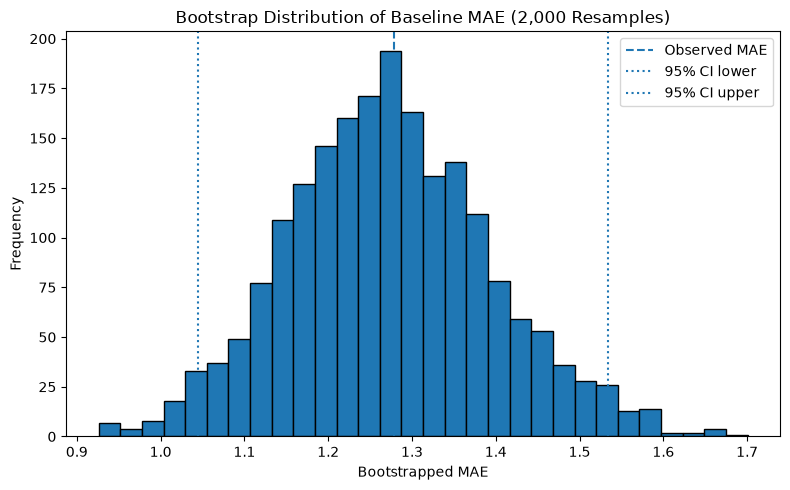

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(mae_boot["samples"], bins=30, edgecolor="black")
plt.axvline(mae_boot["estimate"], linestyle="--", label="Observed MAE")
plt.axvline(mae_boot["lo"], linestyle=":", label="95% CI lower")
plt.axvline(mae_boot["hi"], linestyle=":", label="95% CI upper")
plt.xlabel("Bootstrapped MAE")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Baseline MAE (2,000 Resamples)")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "bootstrap_mae_distribution.png", dpi=160)
plt.show()


**Assumptions:** The bootstrap treats the observed error rows as representative and exchangeable.

**Takeaway:** The baseline MAE is about **1.278**, with a bootstrap 95% interval of approximately **[1.044, 1.534]**. A stakeholder should therefore not interpret 1.278 as an exact future error rate. The uncertainty range is wide enough that operational decisions should use a tolerance band, not a single point estimate.


## 6. Scenario sensitivity

I compare four scenarios so that the analysis changes **two different classes of assumptions**:

### Missing-data assumptions
- **Mean imputation + linear model** — baseline
- **Median imputation + linear model**
- **Complete-case + linear model** — rows with missing \(x\) are excluded

### Model-form assumption
- **Mean imputation + quadratic model**

The complete-case metric is computed only on the correctly aligned non-missing rows. This fixes a potential indexing error in a naive implementation where `y[:len(y_hat)]` would not necessarily correspond to the retained \(x\) rows.


In [8]:
scenario_rows = []
scenario_models = {}

# 1) Baseline: mean imputation + linear
x1, y1 = mean_impute(X_raw), y
m1 = SimpleLinReg().fit(x1, y1)
p1 = m1.predict(x1)
scenario_rows.append({
    "scenario": "Mean imputation + linear",
    "n": len(y1),
    "mae": mae(y1, p1),
    "rmse": rmse(y1, p1),
    "bias": bias(y1, p1),
    "slope_x": m1.coef_[0],
    "quadratic_coef": np.nan,
})
scenario_models["Mean imputation + linear"] = m1

# 2) Median imputation + linear
x2, y2 = median_impute(X_raw), y
m2 = SimpleLinReg().fit(x2, y2)
p2 = m2.predict(x2)
scenario_rows.append({
    "scenario": "Median imputation + linear",
    "n": len(y2),
    "mae": mae(y2, p2),
    "rmse": rmse(y2, p2),
    "bias": bias(y2, p2),
    "slope_x": m2.coef_[0],
    "quadratic_coef": np.nan,
})
scenario_models["Median imputation + linear"] = m2

# 3) Complete-case + linear: the SAME mask is applied to X and y.
mask = ~np.isnan(X_raw)
x3, y3 = X_raw[mask], y[mask]
m3 = SimpleLinReg().fit(x3, y3)
p3 = m3.predict(x3)
scenario_rows.append({
    "scenario": "Complete-case + linear",
    "n": len(y3),
    "mae": mae(y3, p3),
    "rmse": rmse(y3, p3),
    "bias": bias(y3, p3),
    "slope_x": m3.coef_[0],
    "quadratic_coef": np.nan,
})
scenario_models["Complete-case + linear"] = m3

# 4) Mean imputation + quadratic
x4, y4 = mean_impute(X_raw), y
m4 = SimpleLinReg().fit(x4, y4, quadratic=True)
p4 = m4.predict(x4)
scenario_rows.append({
    "scenario": "Mean imputation + quadratic",
    "n": len(y4),
    "mae": mae(y4, p4),
    "rmse": rmse(y4, p4),
    "bias": bias(y4, p4),
    "slope_x": m4.coef_[0],
    "quadratic_coef": m4.coef_[1],
})
scenario_models["Mean imputation + quadratic"] = m4

scenario_results = pd.DataFrame(scenario_rows)
scenario_results["mae_change_vs_baseline_pct"] = (
    scenario_results["mae"] / scenario_results.loc[0, "mae"] - 1
) * 100

scenario_results.to_csv(
    PROCESSED_DIR / "scenario_results.csv", index=False
)

scenario_results


,scenario,n,mae,rmse,bias,slope_x,quadratic_coef,mae_change_vs_baseline_pct
0,Mean imputation + linear,180,1.278317,2.081919,-4.302731e-15,2.130236,NaN,0.000000
1,Median imputation + linear,180,1.283954,2.087957,3.118493e-15,2.129290,NaN,0.440983
2,Complete-case + linear,171,1.064603,1.621860,-1.215402e-15,2.130236,NaN,-16.718354
3,Mean imputation + quadratic,180,1.278111,2.077754,-1.137855e-14,2.293507,-0.01833,-0.016088


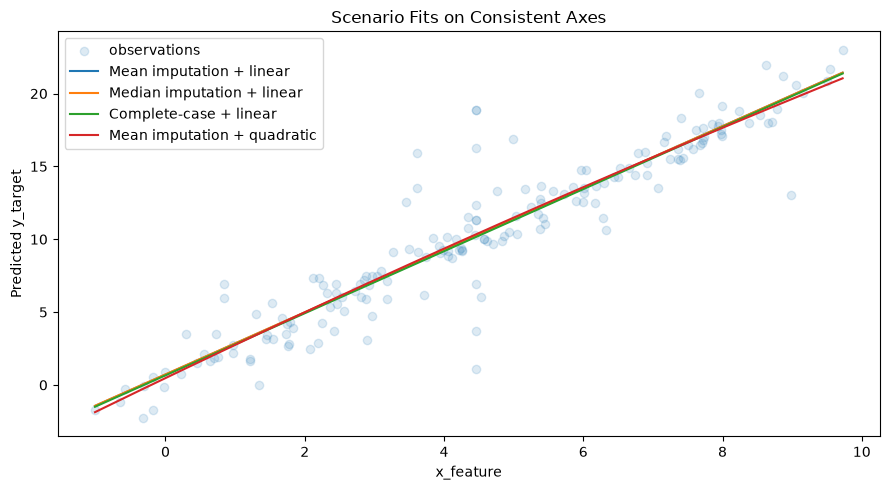

In [9]:
plt.figure(figsize=(9, 5))
plt.scatter(X_base, y, alpha=0.15, label="observations")

for name, model in scenario_models.items():
    plt.plot(x_grid, model.predict(x_grid), label=name)

plt.xlabel("x_feature")
plt.ylabel("Predicted y_target")
plt.title("Scenario Fits on Consistent Axes")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "scenario_fits.png", dpi=160)
plt.show()


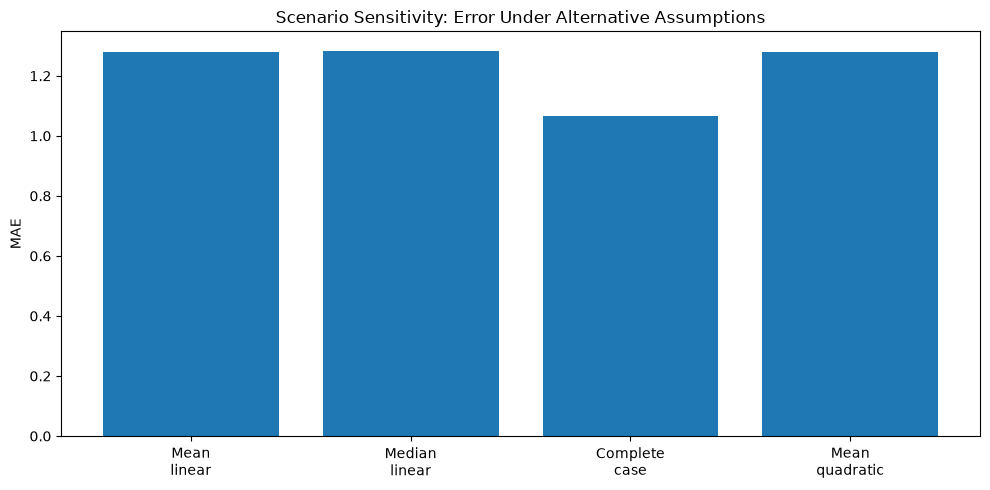

In [10]:
plt.figure(figsize=(10, 5))
positions = np.arange(len(scenario_results))
plt.bar(positions, scenario_results["mae"])
plt.xticks(
    positions,
    [
        "Mean\nlinear",
        "Median\nlinear",
        "Complete\ncase",
        "Mean\nquadratic",
    ],
)
plt.ylabel("MAE")
plt.title("Scenario Sensitivity: Error Under Alternative Assumptions")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "scenario_mae_comparison.png", dpi=160)
plt.show()


**Assumptions:** Mean and median imputation assume missing predictor values can be represented by a central value. Complete-case analysis assumes the omitted rows can be excluded without creating selection problems. The quadratic scenario relaxes the strict linear functional-form assumption.

**Takeaway:** Mean and median imputation give almost identical results (MAE differs by less than 1%), and adding a quadratic term produces essentially no MAE improvement. This supports the linear functional form. In contrast, the complete-case MAE is roughly **17% lower**, but it is calculated on only **171 instead of 180 rows**. That does **not** prove deletion is superior; it shows that conclusions are sensitive to how missing-\(x\) rows are handled and which observations are included in evaluation.


## 7. Subgroup diagnostic

The baseline residuals are compared across segments A, B, and C.

For each group I report:
- sample size
- MAE
- RMSE
- average residual (bias)
- residual standard deviation

I also bootstrap subgroup MAE to visualize uncertainty. Because the groups have different sample sizes, the confidence intervals help distinguish a point estimate from a stable subgroup conclusion.


In [11]:
subgroup = (
    df_eval.groupby("segment")
    .agg(
        n=("residual", "size"),
        mae=("residual", lambda s: float(np.mean(np.abs(s)))),
        rmse=("residual", lambda s: float(np.sqrt(np.mean(np.asarray(s) ** 2)))),
        bias=("residual", "mean"),
        residual_std=("residual", "std"),
    )
    .reset_index()
)

ci_rows = []
for i, row in subgroup.iterrows():
    seg_name = row["segment"]
    seg_resid = df_eval.loc[df_eval["segment"] == seg_name, "residual"].to_numpy()
    bm = bootstrap_abs_error_ci(
        seg_resid,
        n_boot=2000,
        seed=SEED + 100 + i,
    )
    ci_rows.append({
        "segment": seg_name,
        "mae_ci_lo": bm["lo"],
        "mae_ci_hi": bm["hi"],
    })

subgroup = subgroup.merge(pd.DataFrame(ci_rows), on="segment")
subgroup


,segment,n,mae,rmse,bias,residual_std,mae_ci_lo,mae_ci_hi
0,A,94,1.141841,1.818963,-0.066306,1.827501,0.890049,1.436826
1,B,41,0.989357,1.712162,0.294967,1.707514,0.613690,1.458122
2,C,45,1.826674,2.784829,-0.130242,2.813215,1.232602,2.475358


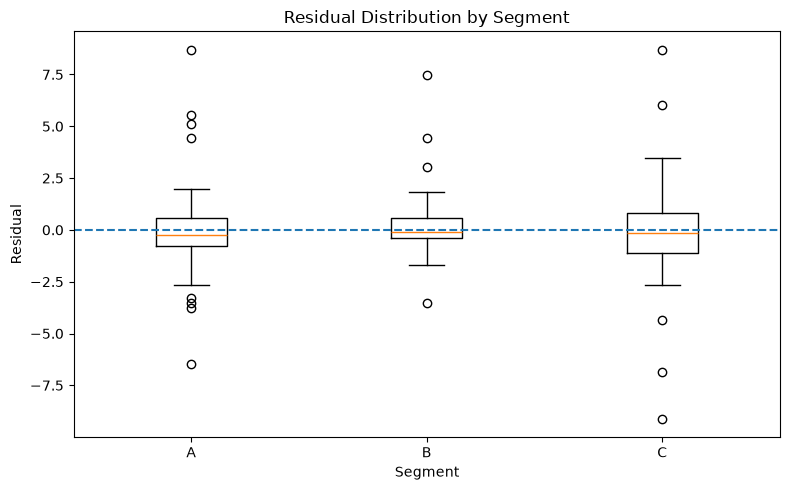

In [12]:
plt.figure(figsize=(8, 5))
grouped = df_eval.groupby("segment")["residual"]
box_data = [values.to_numpy() for _, values in grouped]
box_labels = [name for name, _ in grouped]

plt.boxplot(box_data)
plt.xticks(range(1, len(box_labels) + 1), box_labels)
plt.axhline(0, linestyle="--")
plt.xlabel("Segment")
plt.ylabel("Residual")
plt.title("Residual Distribution by Segment")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "residuals_by_segment.png", dpi=160)
plt.show()


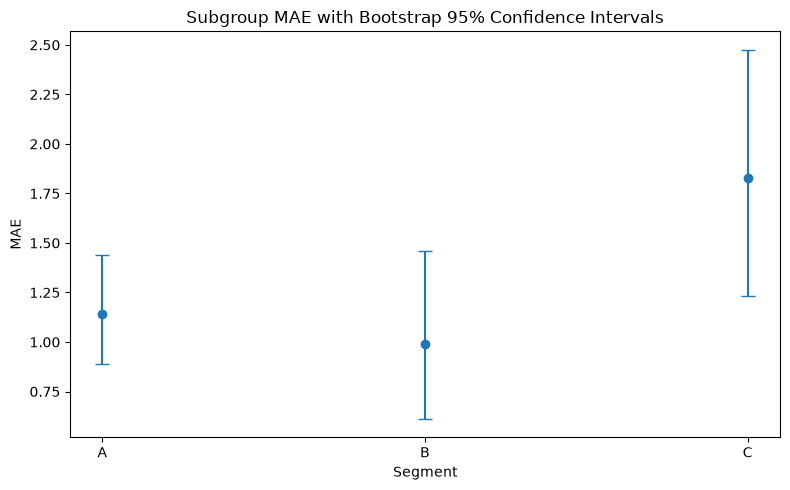

In [13]:
plt.figure(figsize=(8, 5))
xpos = np.arange(len(subgroup))
yerr = np.vstack([
    subgroup["mae"] - subgroup["mae_ci_lo"],
    subgroup["mae_ci_hi"] - subgroup["mae"],
])

plt.errorbar(
    xpos,
    subgroup["mae"],
    yerr=yerr,
    fmt="o",
    capsize=5,
)
plt.xticks(xpos, subgroup["segment"])
plt.xlabel("Segment")
plt.ylabel("MAE")
plt.title("Subgroup MAE with Bootstrap 95% Confidence Intervals")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "subgroup_mae_ci.png", dpi=160)
plt.show()


**Assumptions:** Segment-level comparisons are descriptive. The model does not use segment as a feature, and smaller subgroups have wider uncertainty.

**Takeaway:** Segment C is the clearest hidden-risk area: its MAE is about **1.83**, versus about **1.14** for A and **0.99** for B. Its residual dispersion is also larger. The bootstrap intervals overlap somewhat, so this should be treated as a risk signal rather than proof of a permanent group effect. Still, the aggregate MAE hides materially worse performance for C, so deployment should monitor segment-level errors rather than only the overall metric.


## 8. Stakeholder-facing summary (≤ 1 page)

The baseline model captures the central relationship in the data, but its error should be treated as a range rather than a fixed number. The observed MAE is about **1.28 target units**, and the 95% bootstrap interval is approximately **1.04 to 1.53**. Gaussian-based and bootstrap confidence bands lead to a similar central fitted relationship, which is reassuring, but the data contain fat-tailed errors, so I would not rely on the Gaussian assumption alone.

**Prediction holds if** the relationship between `x_feature` and `y_target` remains approximately linear, the missing-predictor rate stays near the observed **5%**, and future observations are broadly comparable with this sample. Mean versus median imputation changes MAE by less than 1%, and adding a quadratic term produces almost no improvement, so the result is relatively stable to those two assumptions.

The model is more **sensitive to missing-data handling and subgroup composition**. Complete-case analysis reports an MAE about 17% lower than the baseline, but it evaluates only 171 of 180 observations; this is not an apples-to-apples improvement and shows that reported performance can change when difficult or incomplete rows are excluded. Segment C is also a material risk: its MAE is about **1.83**, substantially above segments A and B, with higher residual dispersion.

For stakeholders, I would use the model as a **decision-support estimate, not a guaranteed point forecast**. I would monitor overall MAE, missing-rate, and segment-level error after deployment. I would trigger review if missingness rises materially above the current 5%, if Segment C remains persistently worse with more data, or if bootstrap uncertainty widens. For genuinely time-dependent project data, I would also replace the ordinary row bootstrap with a block bootstrap and re-evaluate performance across time regimes.


## 9. Rubric checklist

### Reproducibility — 2/2 target
- ✅ seed fixed at 111
- ✅ clear data-generation/load steps
- ✅ reusable helper functions saved in `src/evaluation.py`
- ✅ generated outputs saved to `data/processed/` and `reports/`

### Bootstrap CI — 2/2 target
- ✅ 2,000-resample MAE bootstrap
- ✅ 1,500-resample fitted-response bootstrap
- ✅ percentile 95% intervals
- ✅ Gaussian vs bootstrap comparison
- ✅ uncertainty interpretation and exchangeability limitation documented

### Scenarios — 3/3 target
- ✅ mean imputation + linear baseline
- ✅ median imputation + linear
- ✅ complete-case + linear
- ✅ mean imputation + quadratic
- ✅ missing-data and model-form assumptions both tested
- ✅ comparison visuals use consistent axes
- ✅ complete-case X/y alignment corrected
- ✅ assumptions and takeaways stated

### Subgroup diagnostic — 1/1 target
- ✅ A/B/C residual and error metrics
- ✅ subgroup bootstrap intervals
- ✅ Segment C risk identified without overstating certainty

### Stakeholder write-up — 2/2 target
- ✅ plain language
- ✅ explicit “Prediction holds if…”
- ✅ explicit sensitivity statements
- ✅ risks, monitoring triggers, and next steps
- ✅ write-up kept within one page

**Submission filename:** `homework11_evaluation-risk-communication_submission.ipynb`
